In [5]:
using DifferentialEquations
using Plots
#using PlotlyJS
using LinearAlgebra

include("RCP3BP.jl")

getHamiltonianTest (generic function with 1 method)

In [73]:
mu = 0.05
X_L4 = L4(mu)

A = X_H(mu)
vals = eigenValues(mu)
veps = eigenVectors(mu)
v1 = veps[1]
v2 = veps[2]
v3 = veps[3]
v4 = veps[4]

u1 = real(v1 + v2)
u2 = real((v1-v2)*im)
u3 = real(v3+v4)
u4 = real((v3-v4)*im)

4-element Vector{Float64}:
  0.0
  0.7510953047111119
  0.19528932935376575
 -0.6112941003427175

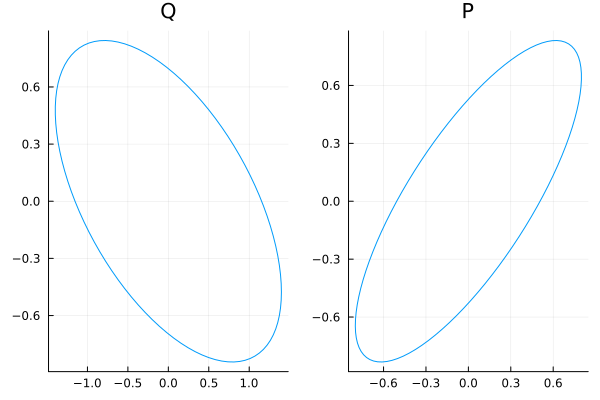

In [74]:
pltQ = plot(1,title="Q",legend=false)
pltP = plot(1,title="P",legend=false)
Q = []
initVec = []
for i = collect(LinRange(0,2pi,100))
    v = (cos(i)*u1 + sin(i)*u2)
    push!(Q,[v[1],v[2]])
    push!(pltQ,v[1],v[2])
    push!(pltP,v[3],v[4])
    push!(initVec, X_L4 + v*(0.1^7))
end

plot(pltQ,pltP)

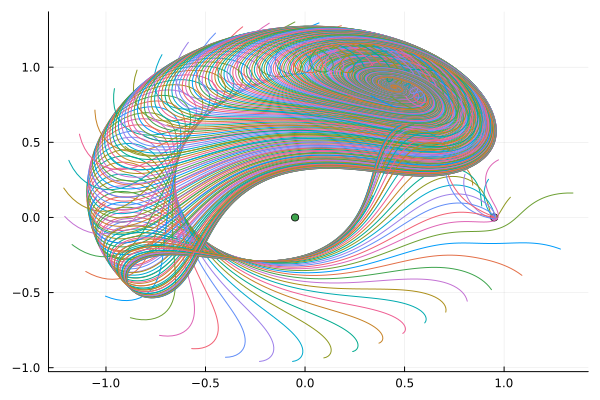

In [88]:
plt = plot(1, legend = false)
plt = plot!([X_L4[1]],[X_L4[2]],seriestype=:scatter)
plt = plot!([-mu],[0],seriestype=:scatter)
plt = plot!([1-mu],[0],seriestype=:scatter)
param = (mu)
tspan = (0.0,93)
for u0 in initVec
    prob = ODEProblem(orbit!,u0,tspan,param)
    sol = solve(prob,Vern9(),dense = false,
        abstol = 1e-14,reltol = 1e-14)
    plt = plot!(sol, idxs=(1,2))
end
plot(plt)

length(sol.t) = 422


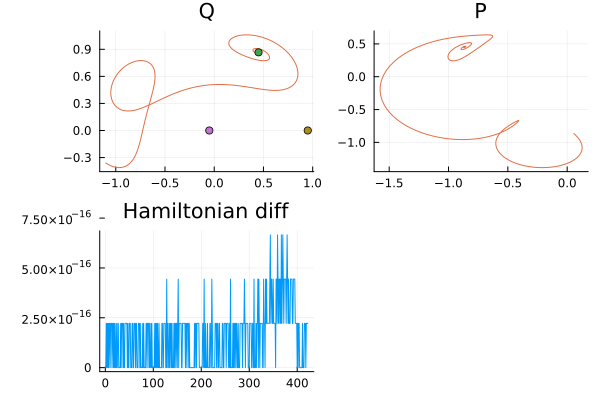

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [106]:
u0 = initVec[30]
tspan = (0.0,93.0)
prob = ODEProblem(orbit!,u0,tspan,param)
sol = solve(prob,Vern9(),dense = false,
        abstol = 1e-14,reltol = 1e-14)

plot(1,legend=false,title="Q")
pltQ = plot!(sol,idxs=(1,2))
pltQ = plot!([X_L4[1]],[X_L4[2]],seriestype=:scatter)
pltQ = plot!([-mu],[0],seriestype=:scatter)
pltQ = plot!([1-mu],[0],seriestype=:scatter)
plot(1,legend=false,title="P")
pltP = plot!(sol,idxs=(3,4))
H = []
for u in sol.u
    H = push!(H,hamiltonian((u[3],u[4]),(u[1],u[2]),(mu)))
end

H = abs.(H .- H[1])

pltH = plot(H,legend=false,title="Hamiltonian diff")

@show length(sol.t)

plot(pltQ,pltP,pltH)


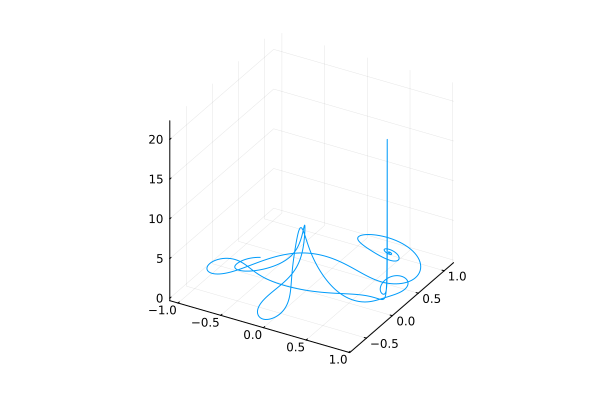

In [104]:
u0 = initVec[10]
tspan = (0.0,99.0)
prob = ODEProblem(orbit!,u0,tspan,param)
sol = solve(prob,Vern9(),dense = false,
        abstol = 1e-14,reltol = 1e-14)

Q = sol[1:2,:]
P = sol[3:4,:]
Plen = sqrt.(P[1,:].^2 + P[2,:].^2)

plot3d(Q[1,:],Q[2,:],Plen,legend=false)